In [2]:
import numpy as np
import cv2 
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
import torch
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms,models
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [4]:
main_path = "/kaggle/input/pets-facial-expression-dataset/Master Folder/"
train_path = main_path+"train/"
val_path = main_path+"valid/"
img_folder = ImageFolder(root=train_path)


# Class Counts and Different Image Sizes

In [5]:
class_counts = {}
image_sizes = {}
for img, img_cls in img_folder:
    if img.size not in image_sizes:
        image_sizes[img.size] = 0
    image_sizes[img.size] += 1
    
    if img_cls not in class_counts:
        class_counts[img_cls] = 0

    class_counts[img_cls] += 1

print(class_counts)
print(image_sizes)

{0: 250, 1: 250, 2: 250, 3: 250}
{(224, 224): 633, (179, 179): 367}


# Augmentations & Transforms

In [6]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

data_transforms = {
    'train':
    transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.01),
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize
    ]),
    'validation':
    transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        normalize
    ]),
}

# Dataset & Dataloader

In [7]:
class PetDataset(Dataset):
    def __init__(self,root_dir,transform=None):
        self.dataset = ImageFolder(root = root_dir,transform=transform)
        self.transform = transform
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self,index):
        image , label  = self.dataset[index]
        samples = {'image':image,'label':label}
        return samples
        

In [8]:
train_dataset = PetDataset(train_path,data_transforms['train'])
val_dataset = PetDataset(val_path,data_transforms['validation'])

In [9]:
train_loader = DataLoader(train_dataset,batch_size = 16,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size = 16,shuffle=False)

Feature batch shape: torch.Size([16, 3, 224, 224])
Labels batch shape: torch.Size([16])


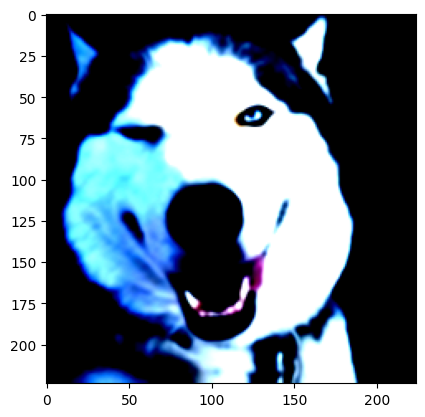

Label: 3


In [10]:
# Display image and label.
batch = next(iter(train_loader))
print(f"Feature batch shape: {batch['image'].size()}")
print(f"Labels batch shape: {batch['label'].size()}")
img = batch['image'][3].squeeze()
label = batch['label'][3]
plt.imshow(img.permute(1, 2, 0))
plt.show()
print(f"Label: {label}")

# Model

In [11]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [16]:
k = 32
compression_factor = 0.5

class DenseLayer(nn.Module):

    def __init__(self,in_channels):
        """
        First 1x1 convolution generating 4*k number of channels irrespective of the total number of input channels.
        First 3x3 convolution generating k number of channels from the 4*k number of input channels.

        Args:
        in_channels (int) : # input channels to the Dense Layer

        """
        super(DenseLayer,self).__init__()

        self.BN1 = nn.BatchNorm2d(num_features = in_channels)
        self.conv1 = nn.Conv2d( in_channels=in_channels , out_channels=4*k , kernel_size=1 , stride=1 , padding=0 , bias = False )

        self.BN2 = nn.BatchNorm2d(num_features = 4*k)
        self.conv2 = nn.Conv2d( in_channels=4*k , out_channels=k , kernel_size=3 , stride=1 , padding=1 , bias = False )

        self.relu = nn.ReLU()

    def forward(self,x):
        xin = x

        x = self.BN1(x)
        x = self.relu(x)
        x = self.conv1(x)


        x = self.BN2(x)
        x = self.relu(x)
        x = self.conv2(x)

        x = torch.cat([xin,x],1)

        return x


class DenseBlock(nn.Module):
    def __init__(self,layer_num,in_channels):
        """
        Looping through total number of layers in the denseblock. 
        Adding k number of channels in each loop as each layer generates tensor with k channels.
        
        Args:
            layer_num (int) : total number of dense layers in the dense block
            in_channels (int) : input number of channels 
        """

        super(DenseBlock,self).__init__()
        self.layer_num = layer_num
        self.deep_nn = nn.ModuleList()

        for num in range(self.layer_num):
            self.deep_nn.add_module(f"DenseLayer_{num}",DenseLayer(in_channels+k*num))


    def forward(self,x):
        """
        Args:
            x (tensor) : input tensor to be passed through the dense block
        
        Attributes:
            x (tensor) : output tensor 
        """
        xin = x

        for layer in self.deep_nn:
            x = layer(x)
        return x


class TransitionLayer(nn.Module):
    def __init__(self,in_channels,compression_factor=0.5):
        """
        1x1 conv used to change output channels using the compression_factor (default = 0.5).
        avgpool used to downsample the feature map resolution 
        
        Args:
            compression_factor (float) : output_channels/input_channels
            in_channels (int) : input number of channels 
        """

        super(TransitionLayer,self).__init__()
        self.BN = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels = in_channels , out_channels = int(in_channels*compression_factor) ,kernel_size = 1 ,stride = 1 ,padding = 0, bias=False )
        self.avgpool = nn.AvgPool2d(kernel_size = 2, stride = 2)

    def forward(self,x):
        """
        Args:
            x (tensor) : input tensor to be passed through the dense block
        
        Attributes:
            x (tensor) : output tensor
        """
        x = self.BN(x)
        x = self.conv1(x)
        x = self.avgpool(x)
        return x



class DenseNet(nn.Module):
    def __init__(self,densenet_variant=[6,12,24,16],in_channels=3,num_classes=4):
        
        """
        Creating an initial 7x7 convolution followed by 3 DenseBlock and 3 Transition layers. Concluding this with 4th DenseBlock, 7x7 global average pool and FC layer
        for classification  
        Args:
            densenet_variant (list) : list containing the total number of layers in a dense block
            in_channels (int) : input number of channels
            num_classes (int) : Total nnumber of output classes 
        
        """

        super(DenseNet,self).__init__()

        # 7x7 conv with s=2 and maxpool
        self.conv1 = nn.Conv2d(in_channels=in_channels ,out_channels=64 ,kernel_size=7 ,stride=2 ,padding=3 ,bias = False)
        self.BN1 = nn.BatchNorm2d(num_features=64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)


        # adding 3 DenseBlocks and 3 Transition Layers 
        self.deep_nn = nn.ModuleList()
        dense_block_inchannels = 64

        for num in range(len(densenet_variant))[:-1]:

            self.deep_nn.add_module( f"DenseBlock_{num+1}" , DenseBlock( densenet_variant[num] , dense_block_inchannels ) )
            dense_block_inchannels  = int(dense_block_inchannels + k*densenet_variant[num])

            self.deep_nn.add_module( f"TransitionLayer_{num+1}" , TransitionLayer( dense_block_inchannels,compression_factor ) )
            dense_block_inchannels = int(dense_block_inchannels*compression_factor)

        # adding the 4th and final DenseBlock
        self.deep_nn.add_module( f"DenseBlock_{num+2}" , DenseBlock( densenet_variant[-1] , dense_block_inchannels ) )
        dense_block_inchannels  = int(dense_block_inchannels + k*densenet_variant[-1])

        self.BN2 = nn.BatchNorm2d(num_features=dense_block_inchannels)

        # Average Pool
        self.average_pool = nn.AdaptiveAvgPool2d(1)
        
        # fully connected layer
        self.fc1 = nn.Linear(dense_block_inchannels, num_classes)


    def forward(self,x):
        """
        deep_nn is the module_list container which has all the dense blocks and transition blocks
        """
        x = self.relu(self.BN1(self.conv1(x)))
        x = self.maxpool(x)
        
        for layer in self.deep_nn:
            x = layer(x)
            
        x = self.relu(self.BN2(x))
        x = self.average_pool(x)

        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)

        return x


model = DenseNet()
model.to(device)

DenseNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (BN1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (deep_nn): ModuleList(
    (0): DenseBlock(
      (deep_nn): ModuleList(
        (0): DenseLayer(
          (BN1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (BN2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (relu): ReLU()
        )
        (1): DenseLayer(
          (BN1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv1): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=F

# Sample Batch

In [17]:
batch = next(iter(train_loader))
model(batch['image'].to(device)).shape

torch.Size([16, 4])

In [18]:
test_output = model(batch['image'].to(device))
print(test_output.argmax(dim=1))

tensor([3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 0], device='cuda:0')


# Loss and Optimizer

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# Training Val Loop

In [20]:
def train_loop(model,loader,epoch):
    train_pred = []
    train_labels = []
    train_loss = 0
    total_samples = 0
    for i,data in enumerate(loader):
        optimizer.zero_grad()
        image = data['image'].to(device)
        label = data['label'].to(device)
        
        outputs = model(image)
        loss = criterion(outputs,label)
        
        loss.backward()
        optimizer.step()
        
        train_loss+= loss.item()
        train_pred.append(torch.argmax(outputs,dim = 1).cpu().detach().numpy())
        train_labels.append(label.cpu().detach().numpy())
        total_samples += data['image'].size(0) 
        
    print("Train Epoch: ",epoch,"| Loss: ",(train_loss/total_samples))
        
    return np.concatenate(train_pred).ravel(), np.concatenate(train_labels).ravel(),(train_loss/total_samples)


def val_loop(model,loader,epoch):
    val_pred = []
    val_labels = []
    val_loss = 0
    total_samples = 0
    with torch.no_grad():
        for i,data in enumerate(loader):
            optimizer.zero_grad()
            image = data['image'].to(device)
            label = data['label'].to(device)
            outputs = model(image)
            loss = criterion(outputs,label)
            val_loss+= loss.item()
            val_pred.append(torch.argmax(outputs,dim = 1).cpu().detach().numpy())
            val_labels.append(label.cpu().detach().numpy())
            total_samples += data['image'].size(0) 
            
        print("Val Epoch: ",epoch,"| Loss: ",(val_loss/total_samples))
        
        return np.concatenate(val_pred).ravel(), np.concatenate(val_labels).ravel(),(val_loss/total_samples)
        
        

In [ ]:
# import torch.optim.lr_scheduler as lr_scheduler


# scheduler = lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)  # Reduce LR every 1 epochs by a factor of 0.5

# num_epochs = 10
# train_preds = []
# train_labels = []
# train_loss_list = []

# val_preds = []
# val_labels = []
# val_loss_list = []

# for i in range(num_epochs):
#     current_lr = optimizer.param_groups[0]['lr']
#     print("Epoch: ", i, "| Learning Rate : ", current_lr)
    
#     model.train()
#     train_preds, train_labels, train_loss = train_val(model, train_loader, i + 1, "train")
#     train_loss_list.append(train_loss)
#     print("Train Accuracy: ", accuracy_score(train_labels, train_preds))
    
#     model.eval()
#     val_preds, val_labels, val_loss = train_val(model, val_loader, i + 1, "val")
#     val_loss_list.append(val_loss)
#     print("Val Accuracy: ", accuracy_score(val_labels, val_preds))
    
#     # Update the learning rate at the end of each epoch
#     scheduler.step()


In [ ]:
import os

# Directory to save models
save_dir = "/kaggle/working/saved_models"
os.makedirs(save_dir, exist_ok=True)

num_epochs = 100
patience = 10  # Number of epochs to wait before reducing the learning rate
learning_rate_decay_facor = 0.5
best_val_accuracy = 0
epochs_since_improvement = 0

train_preds = []
train_labels = []
train_loss_list = []

val_preds = []
val_labels = []
val_loss_list = []

for i in range(num_epochs):
    current_lr = optimizer.param_groups[0]['lr']
    print("Epoch: ", i+1, "| Learning Rate : ", current_lr)
    
    # Train phase
    model.train()
    train_preds, train_labels, train_loss = train_loop(model, train_loader, i + 1)
    train_loss_list.append(train_loss)
    print("Train Accuracy: ", accuracy_score(train_labels, train_preds))
    
    # Validation phase
    model.eval()
    val_preds, val_labels, val_loss = val_loop(model, val_loader, i + 1)
    val_loss_list.append(val_loss)
    val_accuracy = accuracy_score(val_labels, val_preds)
    print("Val Accuracy: ", val_accuracy)
    
    # Check for improvement
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        epochs_since_improvement = 0
        
        # Save the model
        save_path = os.path.join(save_dir, f"best_model_epoch_{i + 1}.pth")
        torch.save(model.state_dict(), save_path)
        print(f"New best model saved to {save_path}.")
    else:
        epochs_since_improvement += 1

    # Reduce the learning rate if no improvement for 'patience' epochs
    if epochs_since_improvement >= patience:
        current_lr = current_lr * learning_rate_decay_facor
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr
        print(f"No improvement for {patience} epochs. Reducing learning rate to {current_lr}.")
        epochs_since_improvement = 0


Epoch:  1 | Learning Rate :  1e-05
Train Epoch:  1 | Loss:  0.08728188478946686
Train Accuracy:  0.305
Val Epoch:  1 | Loss:  0.10142523381445143
Val Accuracy:  0.3611111111111111
New best model saved to /kaggle/working/saved_models/best_model_epoch_1.pth.
Epoch:  2 | Learning Rate :  1e-05


In [ ]:
plt.plot([i+1 for i in range(num_epochs)],train_loss_list,'g',label='Training Loss')
plt.plot([i+1 for i in range(num_epochs)],val_loss_list,'r',label='Val Loss')
plt.title('Training and Testing loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()